# SciPy Bootcamp — Week 1, Day 3A

##### Foundations & The Two-Proportion Test
##### Core A/B testing framework, p-values, two-proportion z-test, effect size, lift
##### Visualization philosophy: charts are woven into the analysis at the point of discovery — not appended at the end.
##### Q1 (Two-proportion z-test pipeline): A digital health platform runs an A/B test on a new appointment booking CTA. Control: 52...
##### Q2 (Effect size — Cohen's h): Using the data from Q1:
# (a) Compute Cohen's h effect size using proportion_eff...
##### Q3 (p-value deep dive): Simulate 2000 A/B tests where H0 is TRUE (both groups same 10% conversion rate, ...
##### Q4 (Absolute vs relative lift — stakeholder communication): You have 3 A/B test results:
# Test 1: control=2%, treatment=3%
# Test 2: contro...
##### Q5 (Revenue impact calculation): The winning treatment from Q1 will be deployed to 80,000 monthly users.
# (a) Ca...


In [90]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

---

### Q1 — Two-proportion z-test pipeline

```
A digital health platform runs an A/B test on a new appointment booking CTA. Control: 5200 users, 338 bookings. Treatment: 5200 users, 416 bookings.
# (a) Compute conversion rates for both groups and visualize them as a bar chart with 95% CI error bars.
# (b) Run a one-tailed two-proportion z-test (alternative='larger').
# (c) Print absolute lift, relative lift, and p-value.
# (d) Interpret: is the result statistically significant? Is it practically meaningful?
# Use: from statsmodels.stats.proportion import proportions_ztest
```


In [91]:
# Q1: Two-proportion z-test pipeline
# Chart + analysis woven together — visualize as you discover

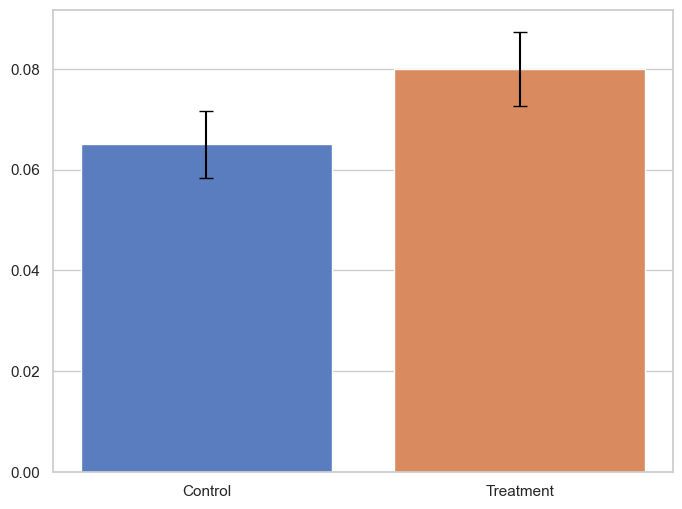

In [92]:
# data setup
n_control = 5200
n_treatment = 5200
conv_control = 338
conv_treatment = 416


# conversion rate
p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

groups = ['Control', 'Treatment']
rates = [p_control, p_treatment]
nobs = [n_control, n_treatment]
counts = [conv_control, conv_treatment]

# Calculate 95% CI bounds
from statsmodels.stats.proportion import proportion_confint

ci_low, ci_high = proportion_confint(counts, nobs, alpha=0.05, method='normal')
errors = [rates[0] - ci_low[0], rates[1] - ci_low[1]] # Margin of error

# plotting
plt.figure(figsize=(8, 6))
barplot = sns.barplot(x=groups, y=rates, palette="muted", capsize=0.1)

# Add error bars manually
plt.errorbar(x=[0, 1], y=rates, yerr=errors, fmt='none', c='black', capsize=5)

plt.show()



---

### Q2 — Effect size — Cohen's h

```
Using the data from Q1:
# (a) Compute Cohen's h effect size using proportion_effectsize from statsmodels.
# (b) Classify it as small/medium/large.
# (c) Plot a dot plot showing both conversion rates with Cohen's h annotated.
# (d) Explain in a comment why a statistically significant result can have a small effect size.
```


In [93]:
# Q2: Effect size — Cohen's h
# Chart + analysis woven together — visualize as you discover

In [94]:
from statsmodels.stats.proportion import proportion_effectsize

h = proportion_effectsize(p_treatment, p_control)
print(f"Cohen's h: {h:.4f}")
print(f'Effect size interpretation: {'very obvious effect' if h >= 0.8 else 'Medium' if h>= 0.5 else 'Small'}')

Cohen's h: 0.0579
Effect size interpretation: Small


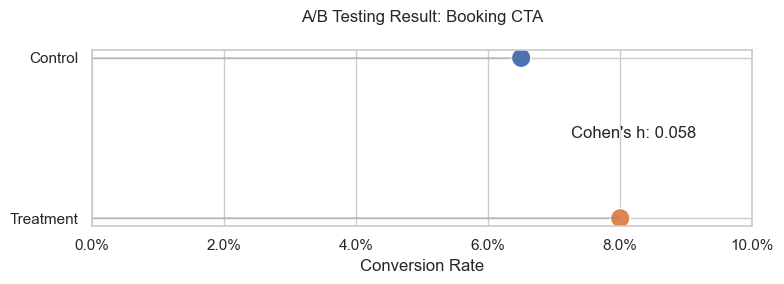

In [95]:
# setup the plot
plt.figure(figsize=(8,3))

# create a dot plot using scatterplot
sns.scatterplot(x=rates, y=groups, hue=groups, s=200, legend=False)

# add a connector line (the "gap")
plt.hlines(y=groups, xmin=0, xmax=rates, alpha=0.3, colors='gray')

# annotate Cohen's h
plt.text((p_control + p_treatment)/2, 0.5, f"Cohen's h: {h:.3f}") 

# formatting
plt.title('A/B Testing Result: Booking CTA', pad=20)
plt.xlabel('Conversion Rate')
plt.xlim(0, 0.1) # Set limit slightly higher th
plt.gca().xaxis.set_major_formatter('{:.1%}'.format) # Show as %

plt.tight_layout()
plt.show()

A signficant p-value can still have a small effect size because 2 of them measure different things. While p-value looks into the signficance of the test result, cohen's h measures the effect of the test. 
A tiny p-value along a low cohen's h is usually due to a large sample size. 

---

### Q3 — p-value deep dive

```
Simulate 2000 A/B tests where H0 is TRUE (both groups same 10% conversion rate, n=1000 each).
# (a) Plot the distribution of p-values as a histogram. What shape do you expect?
# (b) What % fall below 0.05? Is this expected?
# (c) Now repeat with a TRUE effect (treatment = 12%). Overlay both p-value distributions.
# (d) What does this tell you about the relationship between effect size and p-value?
```


In [96]:
# Q3: p-value deep dive
# Chart + analysis woven together — visualize as you discover

In [97]:
# setup parameters
trials = 2000
n = 1000
p = 0.1

# simulate the A/B tests
from statsmodels.stats.proportion import proportions_ztest

control_sim = np.random.binomial(n,p,size=trials)
test_sim = np.random.binomial(n,p,size=trials)

# calculate p-value
p_values = [proportions_ztest([test_sim[i],control_sim[i]], [n,n])[1] for i in range(trials)]

p_values = np.array(p_values)

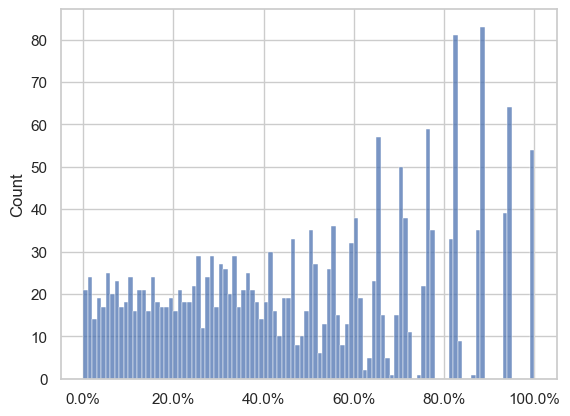

In [98]:
# plotting p-values
sns.histplot(p_values, bins=100)
plt.gca().xaxis.set_major_formatter('{:.1%}'.format) # Show as %
plt.show()

In [99]:
# What % fall below 0.05? Is this expected?
false_positive_rate = np.mean(p_values<0.05)
print(f'{false_positive_rate:.1%} of tests were false positives.')

# the result is as expected!

4.8% of tests were false positives.


41.6% of tests were false positives.
Estimated power: 41.6%


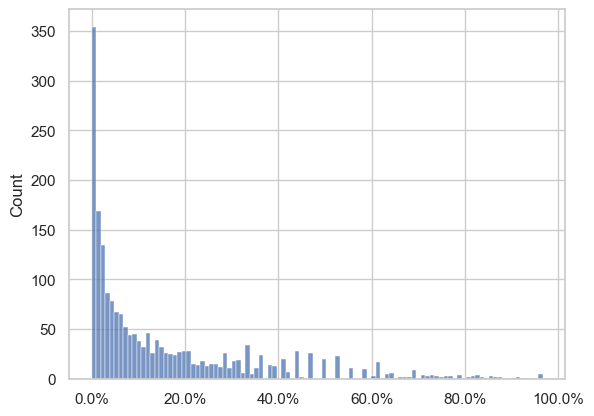

In [ ]:
# Now repeat with a TRUE effect (treatment = 12%). Overlay both p-value distributions.

trials = 2000
n = 1000
p_control = 0.1
p_treatment = 0.12

# simulate the A/B tests
from statsmodels.stats.proportion import proportions_ztest

control_sim = np.random.binomial(n,p_control,size=trials)
test_sim = np.random.binomial(n,p_treatment,size=trials)

# calculate p-value
p_values = [proportions_ztest([test_sim[i],control_sim[i]], [n,n],alternative='larger')[1] for i in range(trials)]
p_values = np.array(p_values)

power = np.mean(p_values < 0.05)
print(f"Estimated power: {power:.1%}")

# plotting p-values
sns.histplot(p_values, bins=100)
plt.gca().xaxis.set_major_formatter('{:.1%}'.format) # Show as %
plt.show()



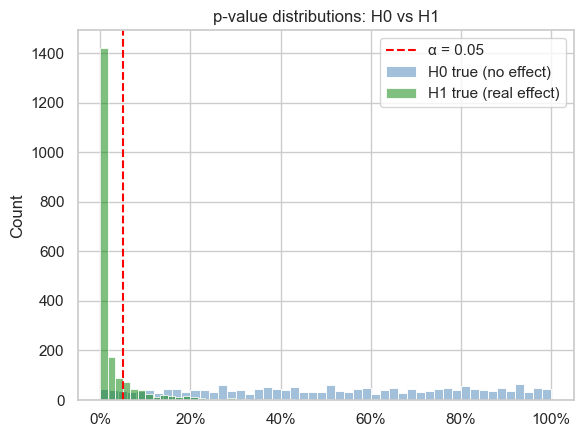

False positive rate: 5.1%  ← expect ~5%
Estimated power:     84.2%  ← how often we detect the real effect


In [103]:
# ── H0 simulation (no real effect: 10% vs 10%) ──────────────────
trials = 2000
n = 3500

control_sim_h0 = np.random.binomial(n, 0.1, size=trials)
test_sim_h0    = np.random.binomial(n, 0.1, size=trials)   # ← same rate, no effect

p_values_h0 = np.array([
    proportions_ztest([test_sim_h0[i], control_sim_h0[i]], [n, n], alternative='larger')[1]
    for i in range(trials)
])

# ── H1 simulation (real effect: 10% vs 12%) ──────────────────────
control_sim_h1 = np.random.binomial(n, 0.1,  size=trials)
test_sim_h1    = np.random.binomial(n, 0.12, size=trials)   # ← different rate, real effect

p_values_h1 = np.array([
    proportions_ztest([test_sim_h1[i], control_sim_h1[i]], [n, n], alternative='larger')[1]
    for i in range(trials)
])

# ── Overlay both distributions ────────────────────────────────────
sns.histplot(p_values_h0, bins=50, alpha=0.5, label='H0 true (no effect)', color='steelblue')
sns.histplot(p_values_h1, bins=50, alpha=0.5, label='H1 true (real effect)', color='green')
plt.axvline(0.05, color='red', linestyle='--', label='α = 0.05')
plt.gca().xaxis.set_major_formatter('{:.0%}'.format)
plt.legend()
plt.title('p-value distributions: H0 vs H1')
plt.show()

# ── Correct interpretations ───────────────────────────────────────
false_positive_rate = np.mean(p_values_h0 < 0.05)  # ← H0 array
power               = np.mean(p_values_h1 < 0.05)  # ← H1 array

print(f"False positive rate: {false_positive_rate:.1%}  ← expect ~5%")
print(f"Estimated power:     {power:.1%}  ← how often we detect the real effect")

---

### Q4 — Absolute vs relative lift — stakeholder communication

```
You have 3 A/B test results:
# Test 1: control=2%, treatment=3%
# Test 2: control=20%, treatment=21%
# Test 3: control=40%, treatment=44%
# (a) Compute absolute lift and relative lift for each.
# (b) Visualize all three as a grouped bar chart (absolute and relative lift side by side).
# (c) Which test has the highest relative lift? Which has the highest absolute lift?
# (d) Write a comment explaining why these two rankings differ and which metric to report to executives vs engineers.
```


In [ ]:
# Q4: Absolute vs relative lift — stakeholder communication
# Chart + analysis woven together — visualize as you discover



In [40]:
# setup data
rate_c = np.array([0.02, 0.2, 0.4])
rate_t = np.array([0.03, 0.21, 0.44])

# compute abs lift and rel lift
abs_lift = rate_t - rate_c
rel_lift = abs_lift / rate_c

print(f'Absolute lift: {abs_lift}')
print(f'Relative lift: {rel_lift}')


Absolute lift: [0.01 0.01 0.04]
Relative lift: [0.5  0.05 0.1 ]


   Control_rate  Treatment_rate  Absolute_lift  Relative_lift  Test
0          0.02            0.03           0.01           0.50     1
1          0.20            0.21           0.01           0.05     2
2          0.40            0.44           0.04           0.10     3
   Test      Lift_type  Value
0     1  Absolute_lift   0.01
1     2  Absolute_lift   0.01
2     3  Absolute_lift   0.04
3     1  Relative_lift   0.50
4     2  Relative_lift   0.05
5     3  Relative_lift   0.10


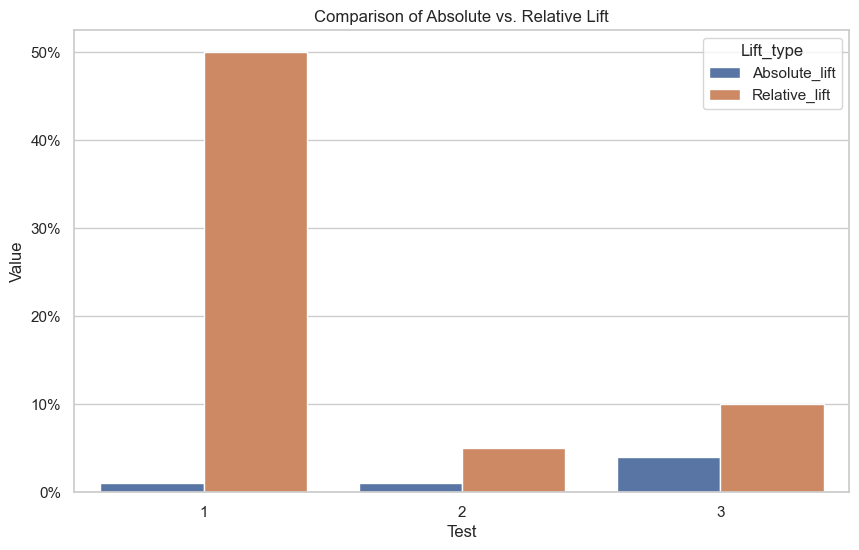

In [56]:
# setting up df
df = pd.DataFrame({
    'Control_rate': rate_c,
    'Treatment_rate': rate_t,
    'Absolute_lift': abs_lift,
    'Relative_lift': rel_lift,
    'Test': [1,2,3]
})
print(df)

# melting data
df_melted = df.melt(
    id_vars='Test',
    value_vars=['Absolute_lift', 'Relative_lift'],
    var_name='Lift_type',
    value_name='Value'
)
print(df_melted)

# plotting
plt.figure(figsize=(10,6))
sns.barplot(
    data = df_melted,
    x='Test',
    y='Value',
    hue='Lift_type'
)

plt.gca().yaxis.set_major_formatter('{:.0%}'.format)
plt.title('Comparison of Absolute vs. Relative Lift')
plt.show()

# (c) Which test has the highest relative lift? Which has the highest absolute lift?
Test 1 has the hightest relative lift while test 3 has the highest absolulte lift

# (d) Write a comment explaining why these two rankings differ and which metric to report to executives vs engineers.
These 2 metrics are different because they use different formulas. For executives, we need to report revenue impact while for engineers, the absolute lift is the go-to

---

### Q5 — Revenue impact calculation

```
The winning treatment from Q1 will be deployed to 80,000 monthly users.
# (a) Calculate expected monthly additional bookings from the lift.
# (b) Assume each booking generates $85 revenue. Calculate monthly and annual revenue impact.
# (c) Build a sensitivity analysis: compute revenue impact for lifts ranging from 0.5pp to 3pp in 0.25pp steps.
# (d) Plot the sensitivity curve. At what lift does annual revenue impact exceed $1M?
# This is the business case calculation you would present to leadership.
```


In [ ]:
# Q5: Revenue impact calculation
# Chart + analysis woven together — visualize as you discover



In [64]:
# data setup
n_control = 5200
n_treatment = 5200
conv_control = 338
conv_treatment = 416


# conversion rate
p_control = conv_control / n_control
p_treatment = conv_treatment / n_treatment

groups = ['Control', 'Treatment']
rates = [p_control, p_treatment]
nobs = [n_control, n_treatment]
counts = [conv_control, conv_treatment]

abs_lift = p_treatment - p_control

print('Absolute Lift:', abs_lift)

# monthly additional booking:
print("Monthly additional booking:", round(abs_lift*80000))
print('Monthly Revenue Impact:', abs_lift*80000*85)
print('Annual Revenue Impact:', abs_lift*80000*85*12)


Absolute Lift: 0.015
Monthly additional booking: 1200
Monthly Revenue Impact: 102000.0
Annual Revenue Impact: 1224000.0


In [72]:
# build a sensitivity analysis: compute revenue impact for lifts ranging from 0.5pp to 3pp in 0.25pp steps.
lifts_pp = np.arange(0.005,0.031,0.0025)
rev_impact = lifts_pp*80000*85*12

# create a sensitivity table
sensitivity_df = pd.DataFrame({
    'Lift_pp': lifts_pp,
    'Annual_Revenue_Impact': rev_impact
})
display(sensitivity_df)

,Lift_pp,Annual_Revenue_Impact
0,0.0050,408000.0
1,0.0075,612000.0
2,0.0100,816000.0
3,0.0125,1020000.0
4,0.0150,1224000.0
5,0.0175,1428000.0
6,0.0200,1632000.0
7,0.0225,1836000.0
8,0.0250,2040000.0
9,0.0275,2244000.0


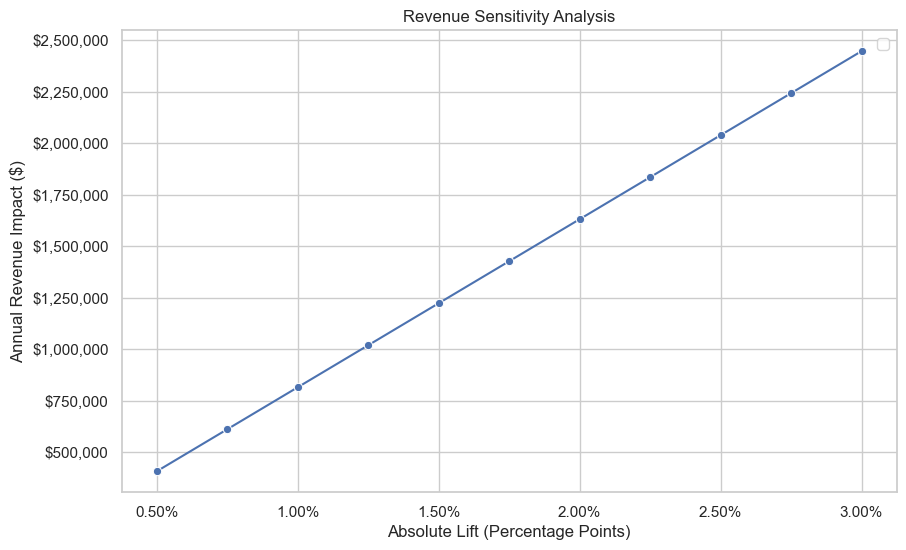

In [80]:
# plot the curve
plt.figure(figsize=(10,6))
sns.lineplot(
    data=sensitivity_df,
    x='Lift_pp',
    y='Annual_Revenue_Impact',
    marker='o'
)
plt.title("Revenue Sensitivity Analysis")
plt.xlabel("Absolute Lift (Percentage Points)")
plt.ylabel("Annual Revenue Impact ($)")
plt.gca().xaxis.set_major_formatter('{:.2%}'.format)
plt.gca().yaxis.set_major_formatter('${:,.0f}'.format)
plt.legend()
plt.show()

In [81]:
# Find the threshold
threshold = sensitivity_df[sensitivity_df['Annual_Revenue_Impact'] >= 1000000].iloc[0]
print(f"Annual revenue exceeds $1M at a lift of: {threshold['Lift_pp']:.2%}")

Annual revenue exceeds $1M at a lift of: 1.25%


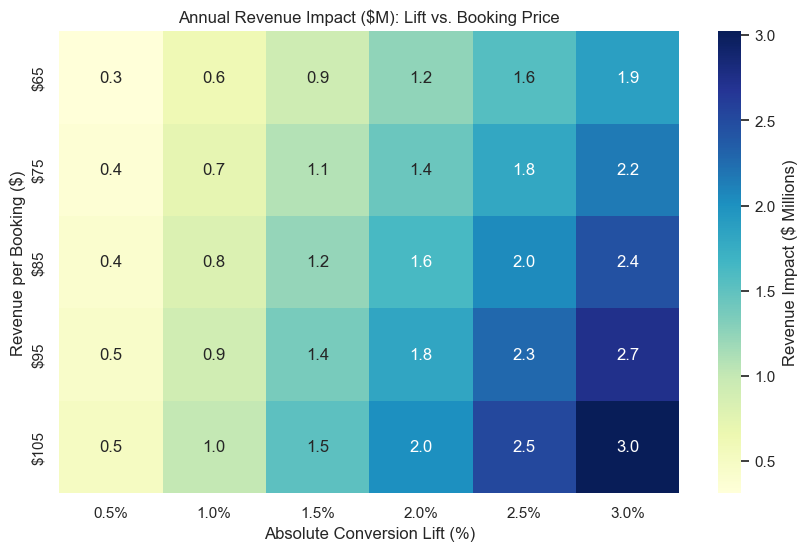

In [87]:
# Creating the Sensitivity Matrix - Heat Map

# 1. Define your "What-if" ranges
lifts = np.arange(0.005, 0.0325, 0.005) # 0.5% to 3.0%
prices = np.array([65, 75, 85, 95, 105]) # $65 to $105 per booking
annual_users = 80000*12

# 2. Build the matrix (Annual Users * Lift * Price)
grid = [[(annual_users * l * p) / 1e6 for l in lifts] for p in prices]

# 3. Format as a DataFrame for Seaborn
df_heat = pd.DataFrame(grid, 
                       index=[f'${p}' for p in prices], 
                       columns=[f'{l:.1%}' for l in lifts])

# 4. Draw the Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_heat, annot=True, fmt=".1f", cmap="YlGnBu", 
            cbar_kws={'label': 'Revenue Impact ($ Millions)'})

plt.title("Annual Revenue Impact ($M): Lift vs. Booking Price")
plt.xlabel("Absolute Conversion Lift (%)")
plt.ylabel("Revenue per Booking ($)")
plt.show()
